# 1. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. LOAD DATA

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [6]:
print("\nInfo:\n")
print(df.info())
print("\nShape:", df.shape)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20

In [9]:
# Rename target
df.rename(columns = {'default.payment.next.month': 'def_pay'}, inplace = True)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,def_pay
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


# 3. DATA UNDERSTANDING

In [10]:
print("\nMissing Values (%):")
print((df.isnull().sum() / len(df)) * 100)

print("\nTarget Distribution:")
print(df['def_pay'].value_counts())


Missing Values (%):
ID           0.0
LIMIT_BAL    0.0
SEX          0.0
EDUCATION    0.0
MARRIAGE     0.0
AGE          0.0
PAY_0        0.0
PAY_2        0.0
PAY_3        0.0
PAY_4        0.0
PAY_5        0.0
PAY_6        0.0
BILL_AMT1    0.0
BILL_AMT2    0.0
BILL_AMT3    0.0
BILL_AMT4    0.0
BILL_AMT5    0.0
BILL_AMT6    0.0
PAY_AMT1     0.0
PAY_AMT2     0.0
PAY_AMT3     0.0
PAY_AMT4     0.0
PAY_AMT5     0.0
PAY_AMT6     0.0
def_pay      0.0
dtype: float64

Target Distribution:
def_pay
0    23364
1     6636
Name: count, dtype: int64


# 4. Exploratory Data Analysis (EDA)

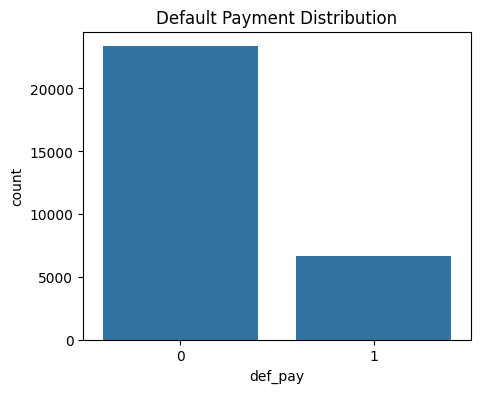

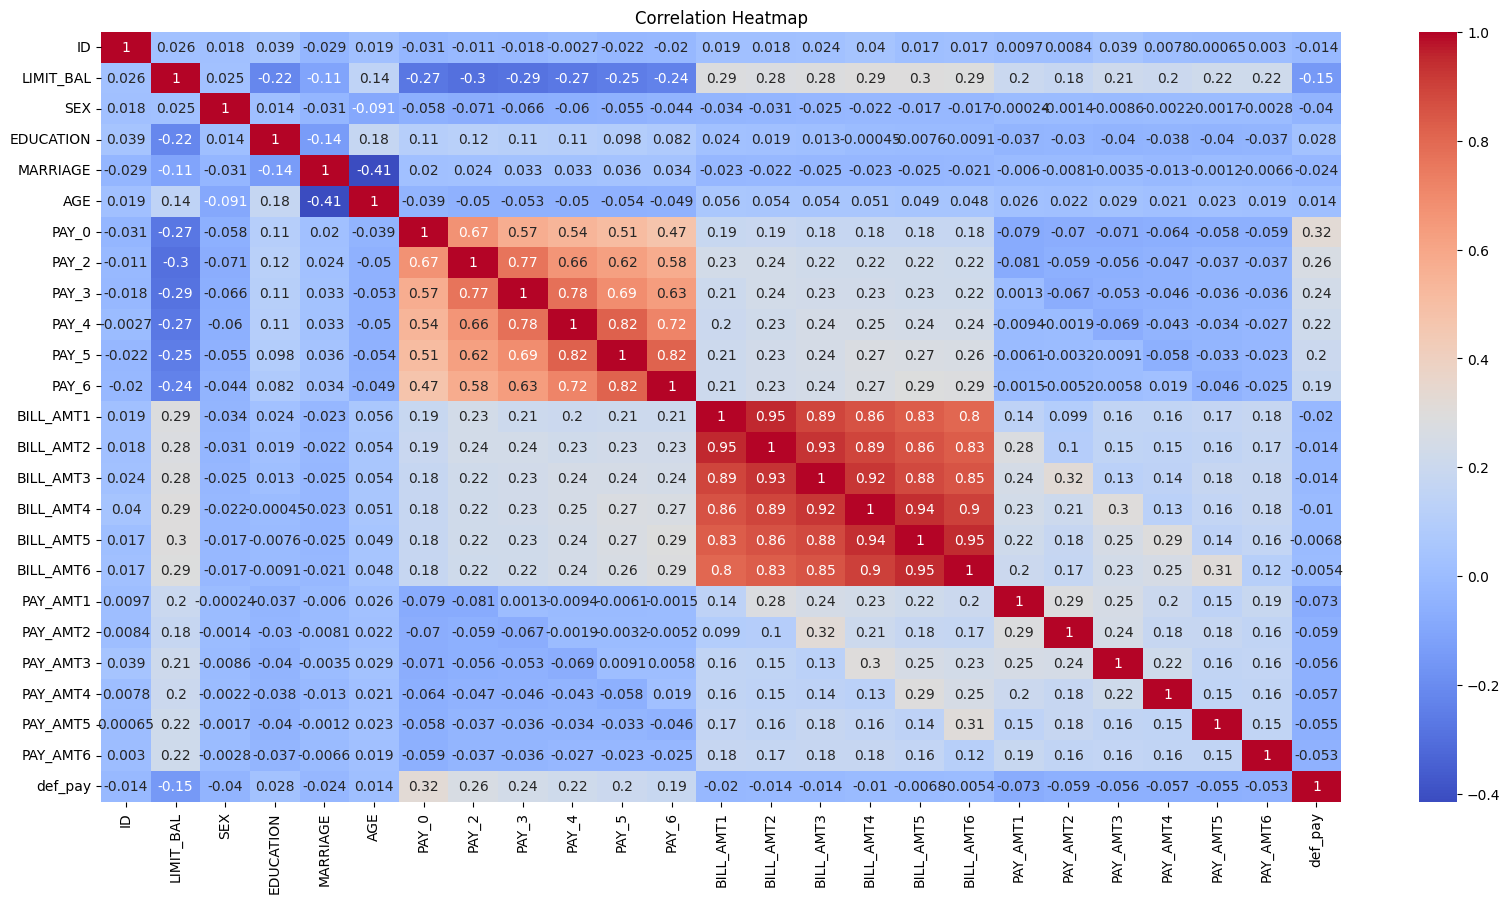

In [13]:
plt.figure(figsize = (5,4))
sns.countplot(data = df, x = 'def_pay')
plt.title("Default Payment Distribution")
plt.show()

plt.figure(figsize = (20,10))
sns.heatmap(df.corr(numeric_only = True), cmap = 'coolwarm', annot = True)
plt.title("Correlation Heatmap")
plt.show()

# 5. DROP IRRELEVANT COLUMNS

In [14]:
df.drop(['ID'], axis = 1, inplace = True)

# 6. OUTLIER REMOVAL (IQR)

In [15]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

num_cols = ['LIMIT_BAL','BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_AMT2']

for col in num_cols:
    df = remove_outliers(df, col)

# 7. FEATURES & TARGET

In [16]:
X = df.drop('def_pay', axis=1)
y = df['def_pay']

# 8. TRAIN TEST SPLIT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# 9. SCALING

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. MODEL COMPARISON (BEFORE TUNING)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [20]:
results_before = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    
    results_before[name] = accuracy_score(y_test, pred)


Before Tuning:
                  Model  Accuracy
0  Logistic Regression  0.780421
1        Random Forest  0.792315


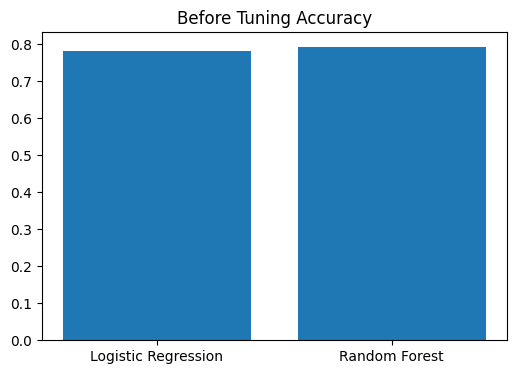

In [23]:
before_df = pd.DataFrame(list(results_before.items()), columns = ['Model','Accuracy'])
print("\nBefore Tuning:\n", before_df)

plt.figure(figsize = (6,4))
plt.bar(before_df['Model'], before_df['Accuracy'])
plt.title("Before Tuning Accuracy")
plt.show()

# 11. HYPERPARAMETER TUNING

In [ ]:
# Logistic Regression
lr_params = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs'],
    'max_iter':[1000]
}

lr_grid = GridSearchCV(LogisticRegression(), lr_params, cv = 5)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_

In [26]:
# Random Forest
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state = 42), rf_params, cv = 5)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# 12. MODEL COMPARISON (AFTER TUNING)

In [27]:
results_after = {}

# Logistic
pred_lr = best_lr.predict(X_test_scaled)
results_after["Tuned Logistic"] = accuracy_score(y_test, pred_lr)

# Random Forest
pred_rf = best_rf.predict(X_test)
results_after["Tuned RF"] = accuracy_score(y_test, pred_rf)


After Tuning:
             Model  Accuracy
0  Tuned Logistic  0.780421
1        Tuned RF  0.790714


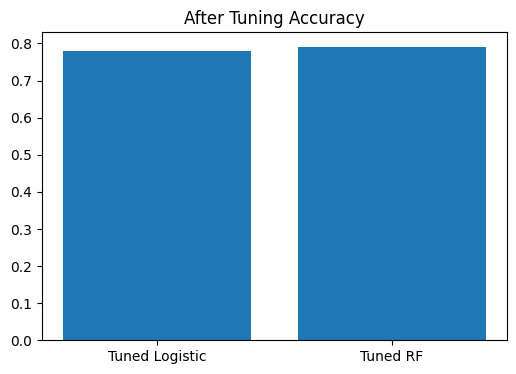

In [28]:
after_df = pd.DataFrame(list(results_after.items()), columns = ['Model','Accuracy'])
print("\nAfter Tuning:\n", after_df)

plt.figure(figsize = (6,4))
plt.bar(after_df['Model'], after_df['Accuracy'])
plt.title("After Tuning Accuracy")
plt.show()

# 13. BEFORE VS AFTER PLOT

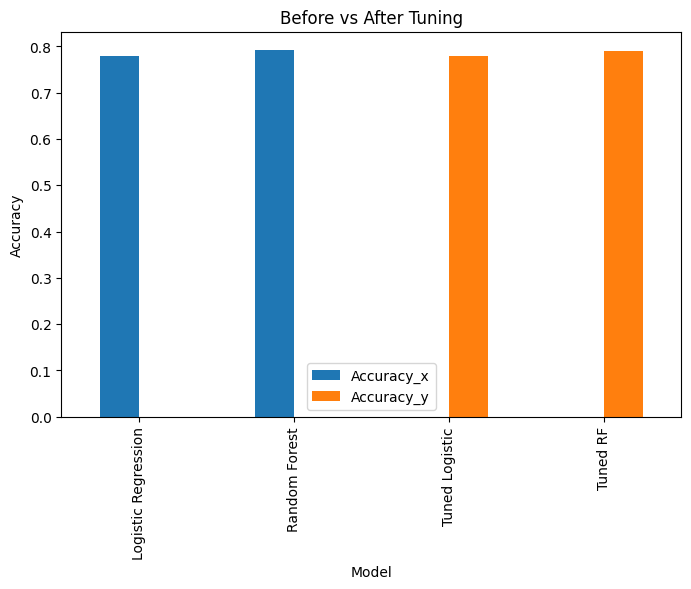

In [29]:
combined = before_df.merge(after_df, on = 'Model', how = 'outer')
combined.set_index('Model').plot(kind = 'bar', figsize = (8,5))
plt.title("Before vs After Tuning")
plt.ylabel("Accuracy")
plt.show()

# 14. BEST MODEL EVALUATION

In [30]:
best_model = best_rf if results_after["Tuned RF"] > results_after["Tuned Logistic"] else best_lr

if best_model == best_lr:
    y_pred = best_lr.predict(X_test_scaled)
else:
    y_pred = best_rf.predict(X_test)

In [31]:
print("\nBest Model Performance:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Model Performance:
[[3108  180]
 [ 735  349]]
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      3288
           1       0.66      0.32      0.43      1084

    accuracy                           0.79      4372
   macro avg       0.73      0.63      0.65      4372
weighted avg       0.77      0.79      0.76      4372



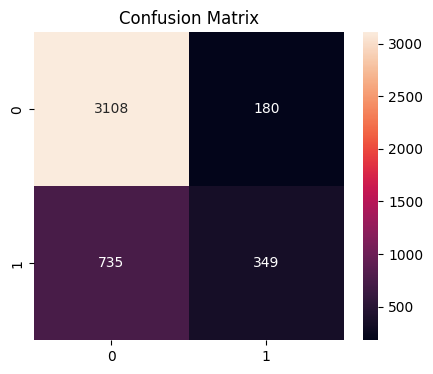

In [32]:
plt.figure(figsize = (5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
plt.title("Confusion Matrix")
plt.show()

# 15. CROSS VALIDATION + PLOT

In [33]:
cv_scores = {}

cv_scores["Logistic"] = cross_val_score(best_lr, X, y, cv = 5)
cv_scores["Random Forest"] = cross_val_score(best_rf, X, y, cv = 5)

c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.

In [34]:
cv_df = pd.DataFrame(cv_scores)

print("\nCV Scores:\n", cv_df)


CV Scores:
    Logistic  Random Forest
0  0.774703       0.782479
1  0.775389       0.789799
2  0.776990       0.799405
3  0.784538       0.815416
4  0.775618       0.800320


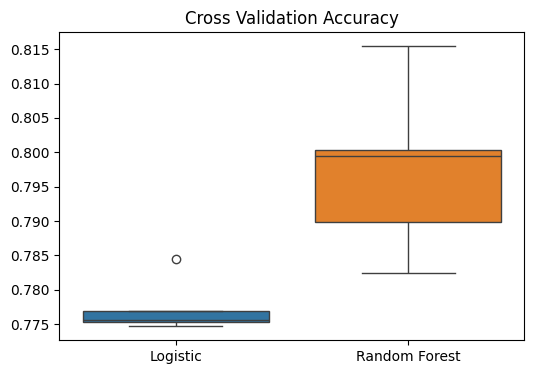

In [35]:
plt.figure(figsize = (6,4))
sns.boxplot(data = cv_df)
plt.title("Cross Validation Accuracy")
plt.show()

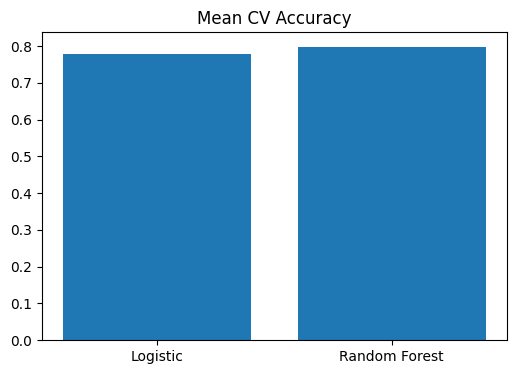

In [36]:
plt.figure(figsize = (6,4))
plt.bar(cv_df.columns, cv_df.mean())
plt.title("Mean CV Accuracy")
plt.show()

# 16. FEATURE IMPORTANCE (RF)

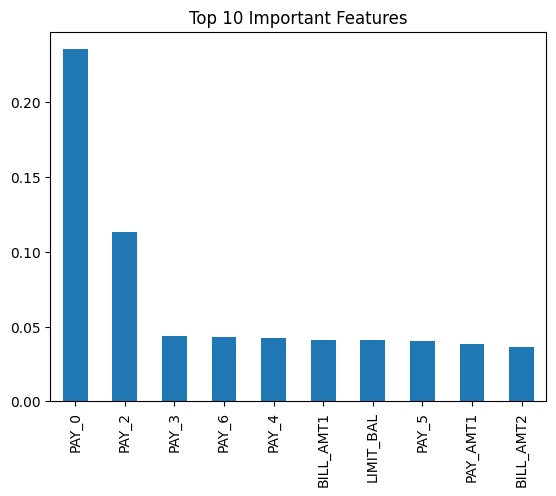

In [37]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()